# AlexNet: Architecture, Image Classification, and Feature Maps

This notebook demonstrates three ideas:

1. build and inspect an AlexNet-style convolutional neural network,
2. train it for image classification on CIFAR-10, and
3. visualize intermediate feature maps to see what the network learns.

> The original AlexNet expects large images and uses a very large classifier. Here we preserve its five-convolution design but adapt the kernels and classifier to 32×32 CIFAR-10 images so the exercise is practical on a laptop.

## 1. AlexNet at a glance

AlexNet alternates learned convolutional filters with nonlinear activation and spatial downsampling. Its main flow is:

`image → conv1 → pool → conv2 → pool → conv3 → conv4 → conv5 → pool → classifier`

Early layers commonly respond to edges and colors. Deeper layers combine those responses into textures, parts, and class-specific patterns. ReLU provides nonlinearity, max pooling reduces spatial size, and dropout regularizes the fully connected classifier.

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using device: {device}')

Using device: cuda


## 2. Load CIFAR-10

CIFAR-10 contains 32×32 color images from ten classes. The training transform adds random crops and flips for data augmentation. Both splits are normalized channel-wise. Set `QUICK_RUN = False` to train on the complete training set.

In [2]:
DATA_DIR = Path('data')
BATCH_SIZE = 128
QUICK_RUN = False
QUICK_TRAIN_SIZE = 10_000
NUM_WORKERS = 0  # portable in notebooks; increase for faster Linux loading

mean = (0.485, 0.456, 0.406)
std  = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_dataset = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=test_transform)
class_names = train_dataset.classes

if QUICK_RUN:
    generator = torch.Generator().manual_seed(SEED)
    indices = torch.randperm(len(train_dataset), generator=generator)[:QUICK_TRAIN_SIZE]
    train_dataset = Subset(train_dataset, indices.tolist())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f'Training images: {len(train_dataset):,}; test images: {len(test_dataset):,}')
print(class_names)

Files already downloaded and verified
Files already downloaded and verified
Training images: 50,000; test images: 10,000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


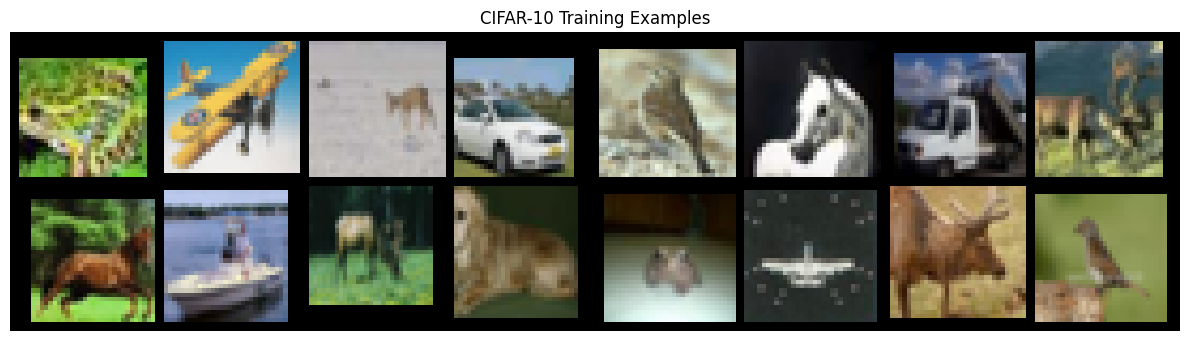

['frog', 'airplane', 'deer', 'automobile', 'bird', 'horse', 'truck', 'deer', 'horse', 'ship', 'deer', 'dog', 'frog', 'airplane', 'deer', 'bird']


In [3]:
def denormalize(images):
    mean_t = torch.tensor(
        mean, dtype=images.dtype, device=images.device
    ).view(1, 3, 1, 1)

    std_t = torch.tensor(
        std, dtype=images.dtype, device=images.device
    ).view(1, 3, 1, 1)

    return (images * std_t + mean_t).clamp(0, 1)


images, labels = next(iter(train_loader))

display_images = denormalize(images[:16]).cpu()
grid = make_grid(display_images, nrow=8, padding=2)

plt.figure(figsize=(12, 4))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("CIFAR-10 Training Examples")
plt.tight_layout()
plt.show()

print([class_names[i] for i in labels[:16].tolist()])

## 3. Build AlexNet

The `features` block contains five convolutional layers. `AdaptiveAvgPool2d` gives the classifier a fixed input size, and the final linear layer produces one score (logit) per class.

In [4]:
class AlexNetCIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # 32×32
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),       # 16×16
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),       # 8×8
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),       # 4×4
        )
        self.avgpool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

model = AlexNetCIFAR(num_classes=len(class_names)).to(device)
model

AlexNetCIFAR(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=4096, out_features=1024, bias=True

In [5]:
def show_tensor_shapes(model, input_shape=(1, 3, 32, 32)):
    x = torch.zeros(input_shape, device=device)
    print(f'Input: {tuple(x.shape)}')
    with torch.no_grad():
        for index, layer in enumerate(model.features):
            x = layer(x)
            print(f'features[{index:2d}] {layer.__class__.__name__:12s} -> {tuple(x.shape)}')
        x = model.avgpool(x)
        print(f'avgpool: {tuple(x.shape)}')
        logits = model.classifier(torch.flatten(x, 1))
        print(f'Output logits: {tuple(logits.shape)}')

show_tensor_shapes(model)
trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print()
print(f'Trainable parameters: {trainable_parameters:,}')

Input: (1, 3, 32, 32)
features[ 0] Conv2d       -> (1, 64, 32, 32)
features[ 1] ReLU         -> (1, 64, 32, 32)
features[ 2] MaxPool2d    -> (1, 64, 16, 16)
features[ 3] Conv2d       -> (1, 192, 16, 16)
features[ 4] ReLU         -> (1, 192, 16, 16)
features[ 5] MaxPool2d    -> (1, 192, 8, 8)
features[ 6] Conv2d       -> (1, 384, 8, 8)
features[ 7] ReLU         -> (1, 384, 8, 8)
features[ 8] Conv2d       -> (1, 256, 8, 8)
features[ 9] ReLU         -> (1, 256, 8, 8)
features[10] Conv2d       -> (1, 256, 8, 8)
features[11] ReLU         -> (1, 256, 8, 8)
features[12] MaxPool2d    -> (1, 256, 4, 4)
avgpool: (1, 256, 4, 4)
Output logits: (1, 10)

Trainable parameters: 6,976,842


## 4. Train the network

Cross-entropy compares the ten logits with the correct label. Backpropagation computes gradients, and AdamW updates all learned convolution and classifier weights. The quick configuration is intended as a demonstration rather than a maximum-accuracy recipe.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-4)
EPOCHS = 3 if QUICK_RUN else 15

def run_epoch(model, loader, training):
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(inputs)
            loss = criterion(logits, targets)
            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_examples += inputs.size(0)

    return total_loss / total_examples, total_correct / total_examples

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, training=True)
    test_loss, test_acc = run_epoch(model, test_loader, training=False)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'train loss {train_loss:.4f}, acc {train_acc:.1%} | '
        f'test loss {test_loss:.4f}, acc {test_acc:.1%}'
    )

Epoch 01/15 | train loss 1.7192, acc 34.9% | test loss 1.4144, acc 50.4%
Epoch 02/15 | train loss 1.2930, acc 53.3% | test loss 1.0665, acc 61.2%
Epoch 03/15 | train loss 1.0735, acc 61.8% | test loss 0.9288, acc 67.3%
Epoch 04/15 | train loss 0.9519, acc 66.6% | test loss 0.8169, acc 71.8%
Epoch 05/15 | train loss 0.8685, acc 69.8% | test loss 0.8065, acc 72.0%
Epoch 06/15 | train loss 0.7977, acc 72.5% | test loss 0.7491, acc 73.9%
Epoch 07/15 | train loss 0.7499, acc 74.2% | test loss 0.6905, acc 76.4%
Epoch 08/15 | train loss 0.7059, acc 75.7% | test loss 0.6742, acc 77.0%
Epoch 09/15 | train loss 0.6748, acc 76.9% | test loss 0.7179, acc 75.2%
Epoch 10/15 | train loss 0.6442, acc 78.0% | test loss 0.6175, acc 78.8%
Epoch 11/15 | train loss 0.6220, acc 78.8% | test loss 0.6265, acc 79.0%
Epoch 12/15 | train loss 0.6002, acc 79.6% | test loss 0.5955, acc 80.0%
Epoch 13/15 | train loss 0.5807, acc 80.2% | test loss 0.5880, acc 80.2%
Epoch 14/15 | train loss 0.5641, acc 80.7% | test l

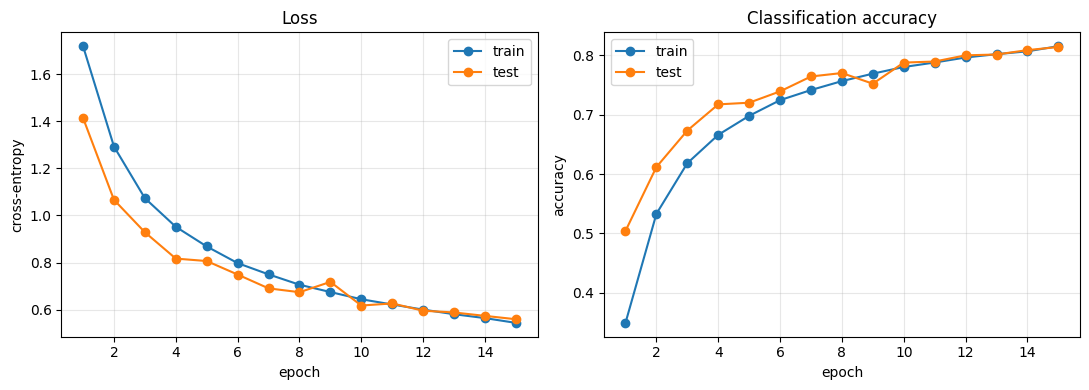

In [7]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, history['train_loss'], 'o-', label='train')
axes[0].plot(epochs, history['test_loss'], 'o-', label='test')
axes[0].set(xlabel='epoch', ylabel='cross-entropy', title='Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(epochs, history['train_acc'], 'o-', label='train')
axes[1].plot(epochs, history['test_acc'], 'o-', label='test')
axes[1].set(xlabel='epoch', ylabel='accuracy', title='Classification accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "loss_acc_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 5. Inspect predictions

Green titles indicate correct predictions; red titles indicate errors.

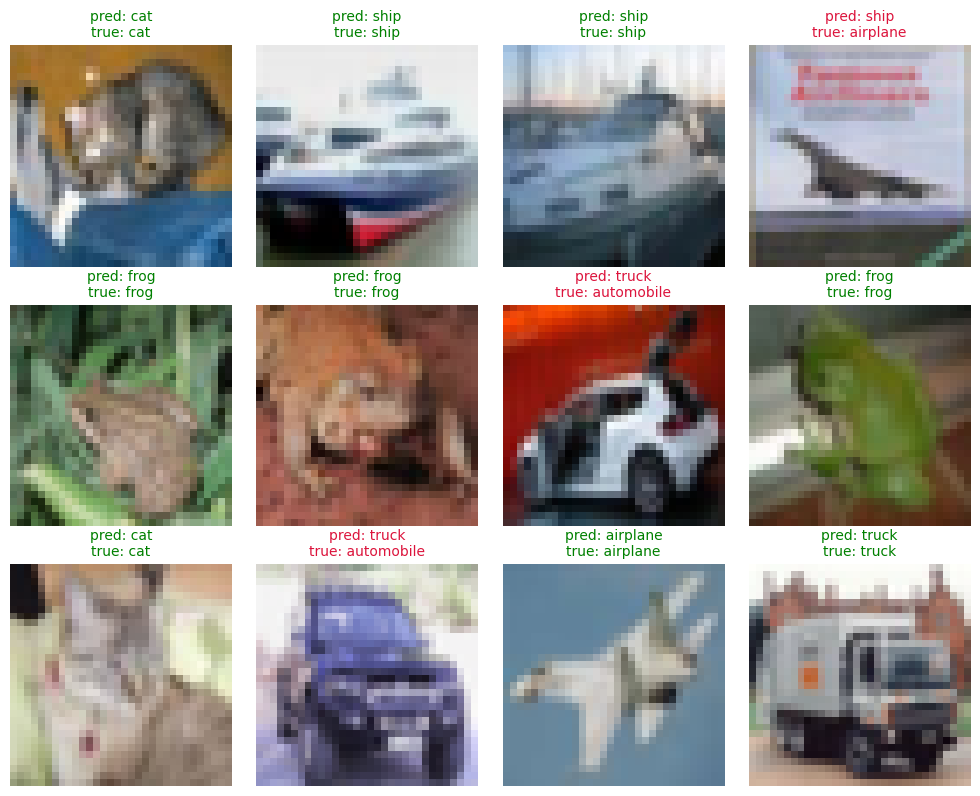

In [8]:
model.eval()
test_images, test_labels = next(iter(test_loader))
with torch.no_grad():
    predictions = model(test_images.to(device)).argmax(dim=1).cpu()

display_images = denormalize(test_images[:12])
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for ax, image, label, prediction in zip(axes.flat, display_images, test_labels, predictions):
    ax.imshow(image.permute(1, 2, 0))
    color = 'green' if prediction == label else 'crimson'
    title = f'pred: {class_names[prediction]}' + chr(10) + f'true: {class_names[label]}'
    ax.set_title(title, color=color, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(
    "pred_true_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 6. Visualize intermediate feature maps

Forward hooks record a layer's output without changing the model. We attach one hook after each convolutional ReLU, pass a single image through the network, and display the first activation channels at each depth. A channel is shown independently because activation magnitudes differ across layers.

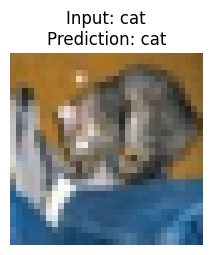

In [9]:
activation_layers = {
    'conv1': model.features[1],
    'conv2': model.features[4],
    'conv3': model.features[7],
    'conv4': model.features[9],
    'conv5': model.features[11],
}
activations = {}
hooks = []

def save_activation(name):
    def hook(_module, _inputs, output):
        activations[name] = output.detach().cpu()
    return hook

for name, layer in activation_layers.items():
    hooks.append(layer.register_forward_hook(save_activation(name)))

sample_image = test_images[0:1].to(device)
model.eval()
with torch.no_grad():
    sample_logits = model(sample_image)

for hook in hooks:
    hook.remove()

predicted_class = class_names[sample_logits.argmax(dim=1).item()]
true_class = class_names[test_labels[0].item()]
plt.figure(figsize=(2.5, 2.5))
plt.imshow(denormalize(test_images[0:1])[0].permute(1, 2, 0))
title = f'Input: {true_class}' + chr(10) + f'Prediction: {predicted_class}'
plt.title(title)
plt.axis('off')
plt.show()

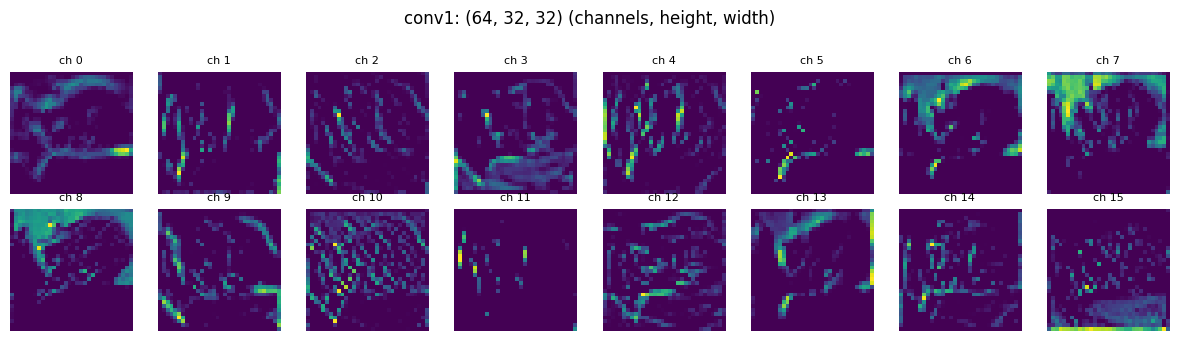

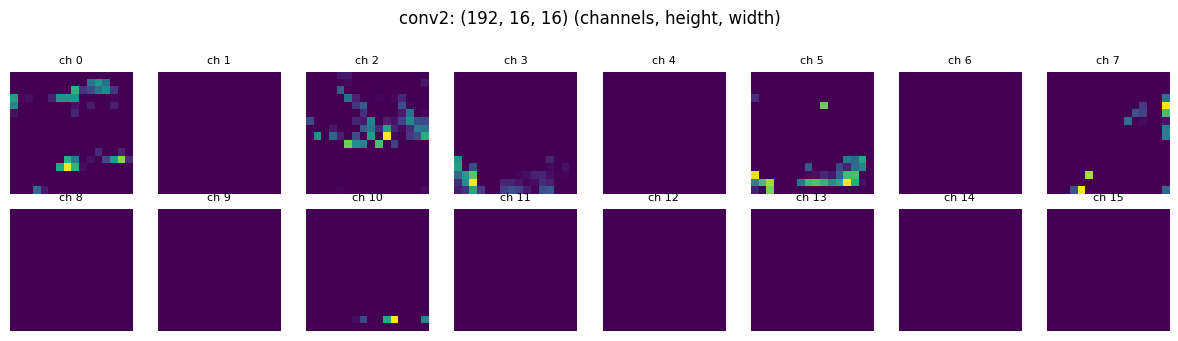

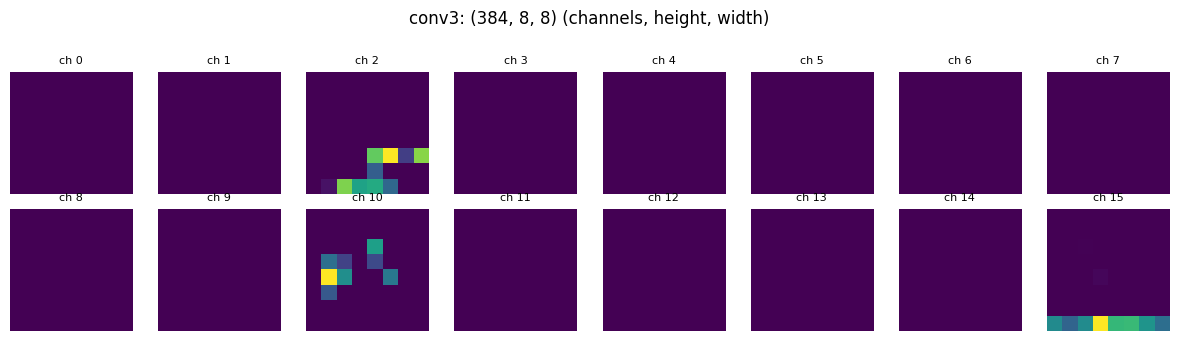

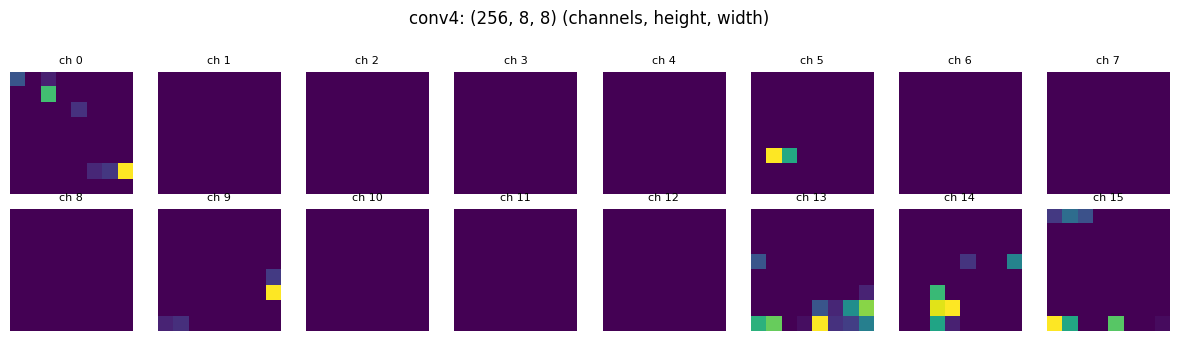

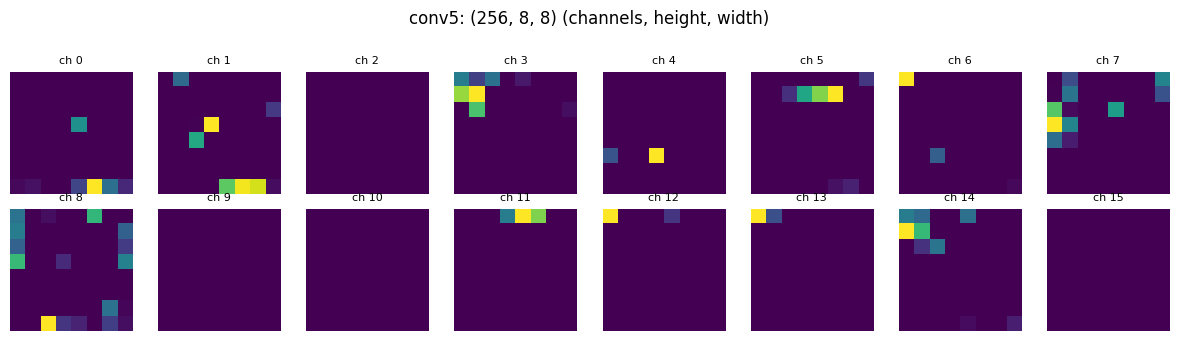

In [10]:
def plot_feature_maps(activation, layer_name, max_channels=16):
    maps = activation[0]
    count = min(max_channels, maps.shape[0])
    columns = 8
    rows = int(np.ceil(count / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(12, 1.65 * rows), squeeze=False)
    for channel, ax in enumerate(axes.flat):
        if channel < count:
            feature = maps[channel]
            ax.imshow(feature, cmap='viridis')
            ax.set_title(f'ch {channel}', fontsize=8)
        ax.axis('off')
    fig.suptitle(f'{layer_name}: {tuple(maps.shape)} (channels, height, width)', y=1.02)
    plt.tight_layout()
    plt.savefig(
        f"{layer_name}_feature_maps.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

for layer_name, activation in activations.items():
    plot_feature_maps(activation, layer_name)

### What to look for

- **Conv1:** edges, color contrasts, and simple local patterns.
- **Conv2:** combinations of edges and small textures.
- **Conv3–Conv5:** increasingly selective and spatially abstract patterns.
- Dark or nearly uniform maps mean that a channel responds weakly to this particular image; they do not necessarily mean the channel is unused.

Try a different `test_images` index, train for more epochs, or rank channels by mean activation instead of displaying the first 16 channels.

## 7. Visualize learned convolution kernels

Feature maps show a layer's response to one image; kernels show the weights that produce those responses. Each Conv1 kernel has three input channels, so it can be normalized and displayed as a small RGB image. After training, these filters often resemble color contrasts and oriented edge detectors.

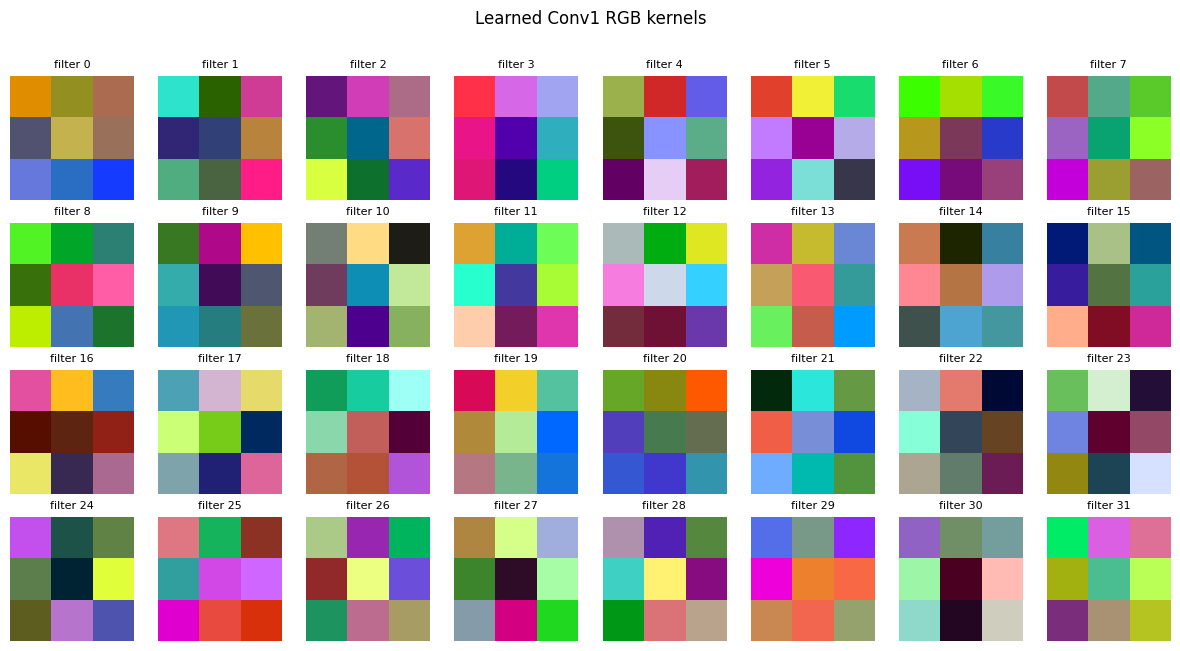

In [11]:
def normalize_for_display(tensor):
    tensor = tensor.detach().cpu()
    low, high = tensor.min(), tensor.max()
    return (tensor - low) / (high - low + 1e-8)

conv1_weights = model.features[0].weight
num_kernels = min(32, conv1_weights.shape[0])
columns = 8
rows = int(np.ceil(num_kernels / columns))
fig, axes = plt.subplots(rows, columns, figsize=(12, 1.6 * rows), squeeze=False)

for kernel_index, ax in enumerate(axes.flat):
    if kernel_index < num_kernels:
        kernel = normalize_for_display(conv1_weights[kernel_index])
        ax.imshow(kernel.permute(1, 2, 0), interpolation='nearest')
        ax.set_title(f'filter {kernel_index}', fontsize=8)
    ax.axis('off')

fig.suptitle('Learned Conv1 RGB kernels', y=1.01)
plt.tight_layout()
plt.show()

Deeper kernels cannot be displayed as RGB because they operate on many input feature channels. The visualization below computes the root-mean-square weight across all input channels, giving one 2D magnitude map per output kernel. Brighter locations have larger weights, regardless of sign.

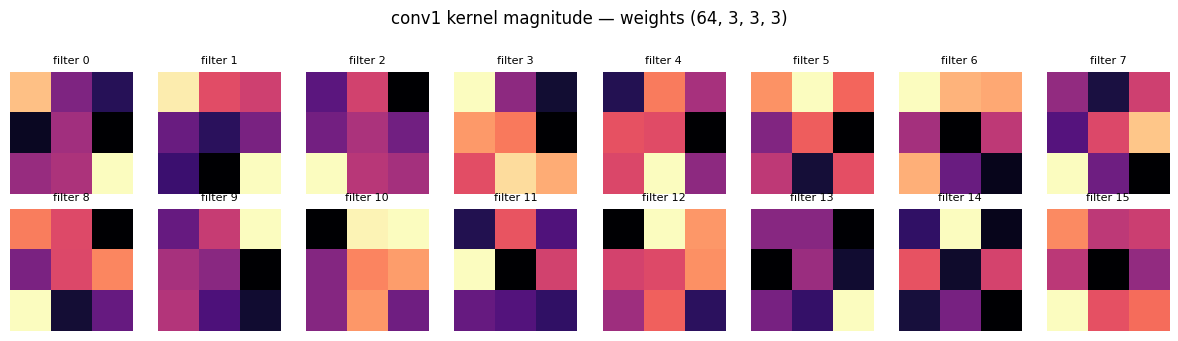

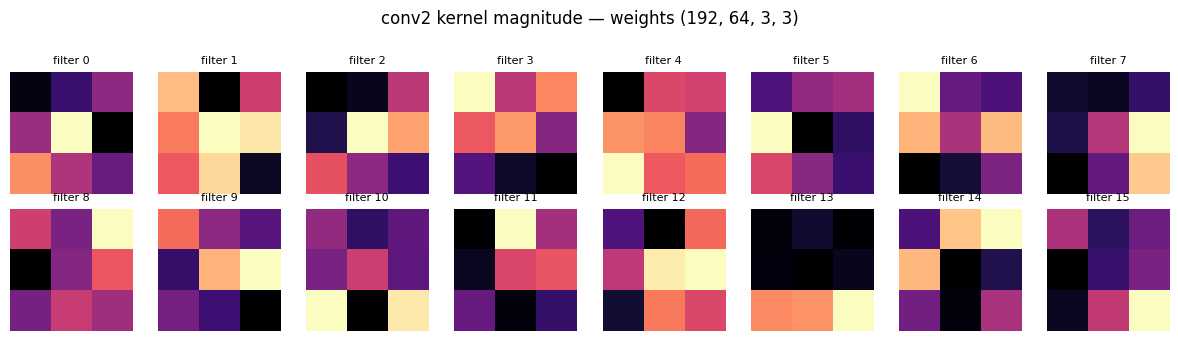

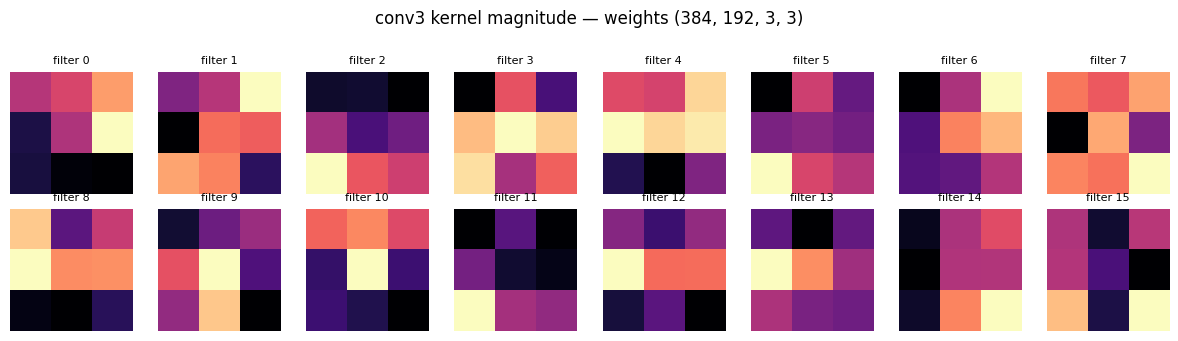

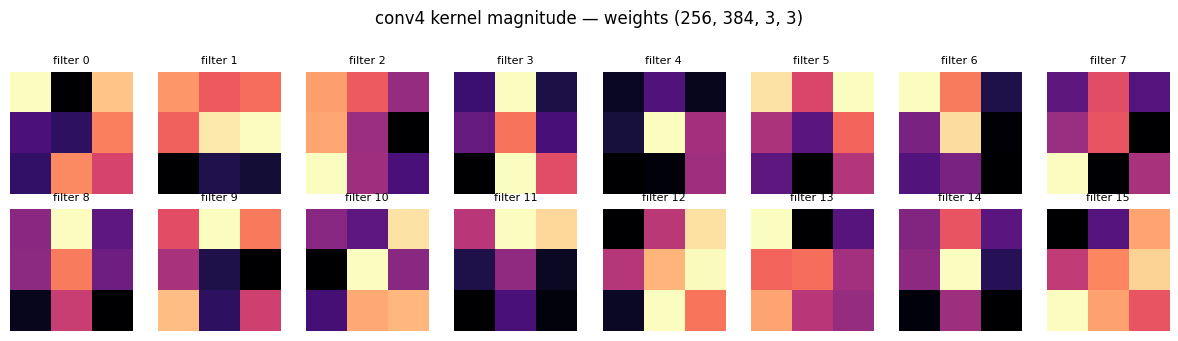

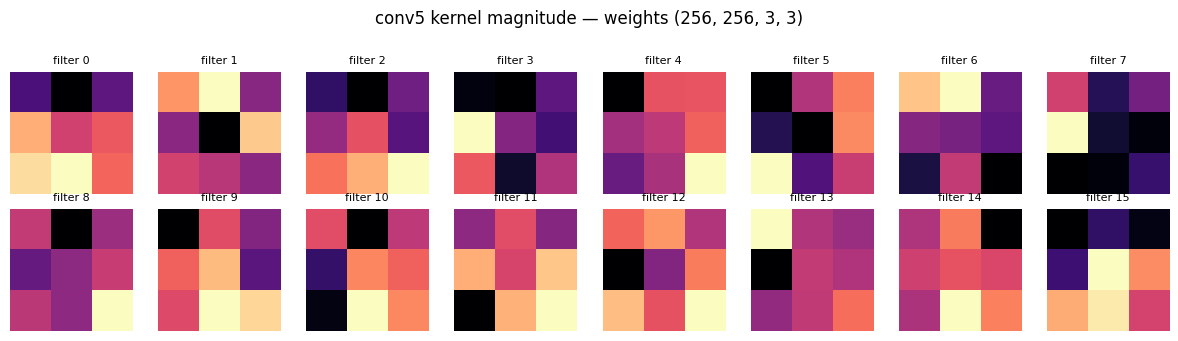

In [12]:
conv_layers = {
    'conv1': model.features[0],
    'conv2': model.features[3],
    'conv3': model.features[6],
    'conv4': model.features[8],
    'conv5': model.features[10],
}

def plot_kernel_magnitudes(layer, layer_name, max_kernels=16):
    weights = layer.weight.detach().cpu()
    magnitude = torch.sqrt(torch.mean(weights ** 2, dim=1))
    count = min(max_kernels, magnitude.shape[0])
    columns = 8
    rows = int(np.ceil(count / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(12, 1.65 * rows), squeeze=False)

    for kernel_index, ax in enumerate(axes.flat):
        if kernel_index < count:
            image = magnitude[kernel_index]
            ax.imshow(image, cmap='magma', interpolation='nearest')
            ax.set_title(f'filter {kernel_index}', fontsize=8)
        ax.axis('off')

    fig.suptitle(
        f'{layer_name} kernel magnitude — weights {tuple(weights.shape)}',
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

for layer_name, layer in conv_layers.items():
    plot_kernel_magnitudes(layer, layer_name)

## Optional exercises

1. Set `QUICK_RUN = False` and compare accuracy after 15 epochs.
2. Remove dropout and compare the train/test curves.
3. Visualize the learned kernels in the first convolutional layer.
4. Replace AlexNet with a small residual network and compare parameter count and accuracy.
5. Display the channels with the largest mean activation for the selected image.